In [1]:
#installing the required packages
!!pip install pandas wbdata matplotlib seaborn

['Requirement already satisfied: pandas in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (3.0.1)',
 'Requirement already satisfied: wbdata in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (1.1.0)',
 'Requirement already satisfied: matplotlib in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (3.10.8)',
 'Requirement already satisfied: seaborn in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (0.13.2)',
 'Requirement already satisfied: numpy>=1.26.0 in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (from pandas) (2.4.2)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (from pandas) (2.9.0.post0)',
 'Requirement already satisfied: tzdata in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (from pandas) (2025.3)',
 'Requirement already satisfied: appdirs<2,>=1.4 in c:\\users\\user\\anaconda3\\envs\\maji_ql\\lib\\site-packages (f

In [2]:
#importing libraries
import pandas as pd
import wbdata
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Defining the Time Range we want
#We want 1990–2023
data_date = (datetime.datetime(1990, 1, 1), datetime.datetime(2023, 1, 1))
data_date


(datetime.datetime(1990, 1, 1, 0, 0), datetime.datetime(2023, 1, 1, 0, 0))

In [4]:
#Selecting indicators from the World Bank
indicators = {
    "SP.POP.TOTL": "population",
    "AG.PRD.FOOD.XD": "food_production_index",
    "SN.ITK.DEFC.ZS": "undernourishment",
    "AG.CON.FERT.ZS": "fertilizer_consumption"
}

In [5]:
#downloading the Ghana dataset
df = wbdata.get_dataframe(
    indicators,
    country="GHA",
    date=data_date
)

df = df.reset_index()
df = df.sort_values("date")

df.head()

,date,population,food_production_index,undernourishment,fertilizer_consumption
33,1990,15394648.0,24.93,NaN,4.814815
32,1991,15787496.0,35.83,NaN,2.857143
31,1992,16184855.0,35.34,NaN,3.607143
30,1993,16589519.0,38.08,NaN,2.702857
29,1994,16993190.0,37.07,NaN,2.750000


In [6]:
#Renaming the date column
df["year"] = df["date"]
df = df.drop(columns="date")
df = df.sort_values("year")

df.head()

,population,food_production_index,undernourishment,fertilizer_consumption,year
33,15394648.0,24.93,NaN,4.814815,1990
32,15787496.0,35.83,NaN,2.857143,1991
31,16184855.0,35.34,NaN,3.607143,1992
30,16589519.0,38.08,NaN,2.702857,1993
29,16993190.0,37.07,NaN,2.750000,1994


In [7]:
#checking for missing values
df.isnull().sum()

population                 0
food_production_index      1
undernourishment          11
fertilizer_consumption     0
year                       0
dtype: int64

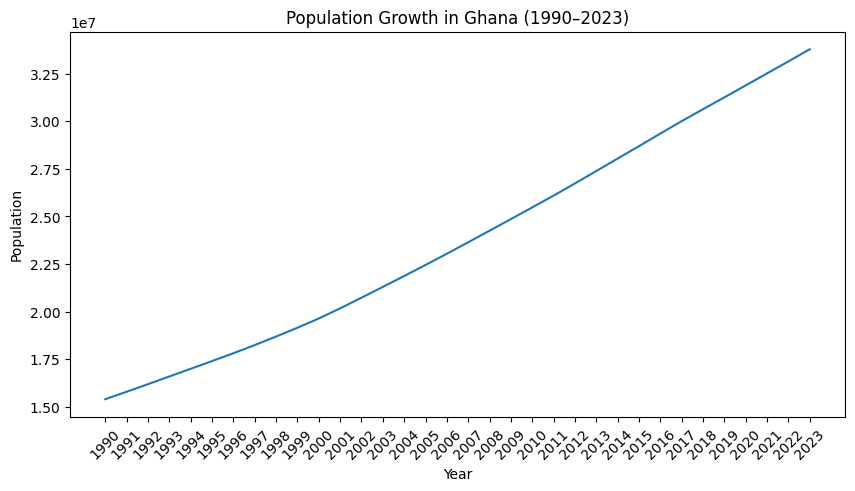

In [8]:
#visualizing population trends
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="year", y="population")

plt.title("Population Growth in Ghana (1990–2023)")
plt.xlabel("Year")
plt.ylabel("Population")

plt.xticks(rotation=45) # rotate year labels

plt.savefig("population_trend.png", dpi=300, bbox_inches="tight")

plt.show()

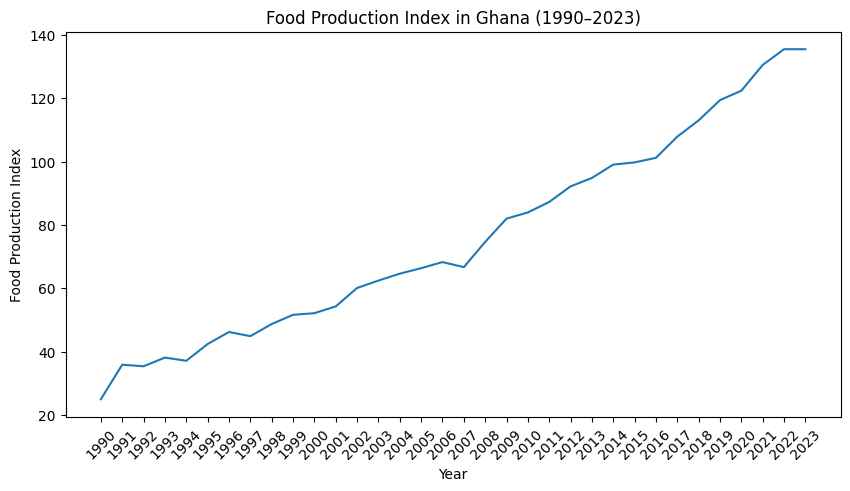

In [11]:
#visualizing the food production trends
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="year", y="food_production_index")

plt.title("Food Production Index in Ghana (1990–2023)")
plt.xlabel("Year")
plt.ylabel("Food Production Index")

plt.xticks(rotation=45) #rotate year labels

plt.savefig("food_production_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
#Handling missing value in food production index using interpolation
df["food_production_index"] = df["food_production_index"].interpolate()

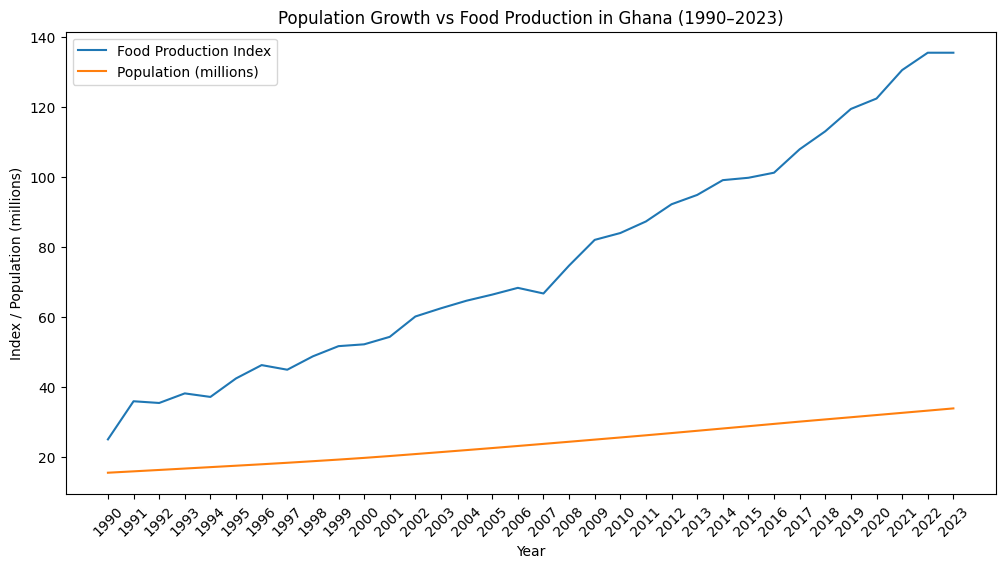

In [12]:
#Now we create a comparison between population and food production.
#This helps answer the core question: Is food production keeping up with population growth?
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="year", y="food_production_index", label="Food Production Index")
sns.lineplot(data=df, x="year", y=df["population"]/1000000, label="Population (millions)") #to ensure chart readability

plt.title("Population Growth vs Food Production in Ghana (1990–2023)")
plt.xlabel("Year")
plt.ylabel("Index / Population (millions)")

plt.xticks(rotation=45)

plt.legend()

plt.savefig("production_vs_population_trend.png", dpi=300, bbox_inches="tight")
plt.show()

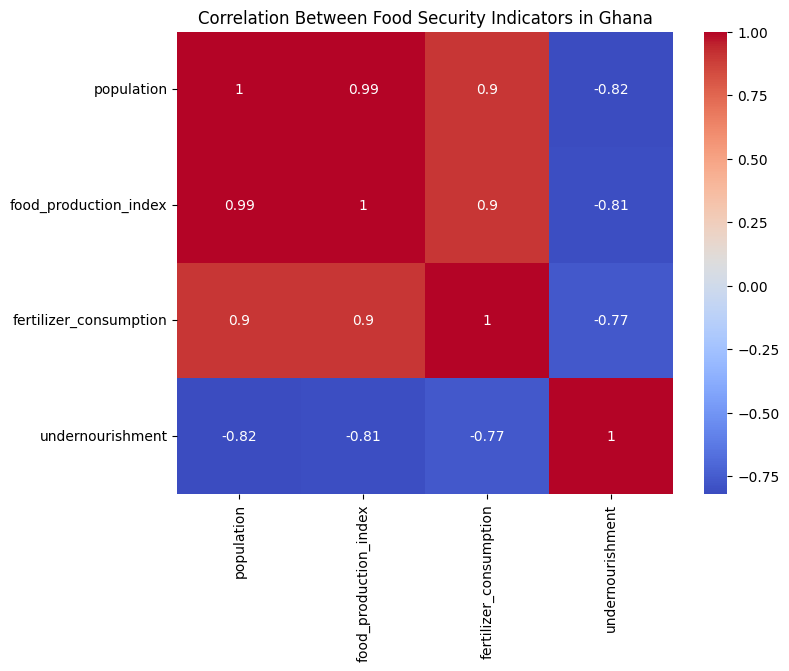

In [13]:
#Building a correlation heatmap to determine Which factors are most related to undernourishment in Ghana?
plt.figure(figsize=(8,6))

correlation = df[[
    "population",
    "food_production_index",
    "fertilizer_consumption",
    "undernourishment"
]].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Food Security Indicators in Ghana")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

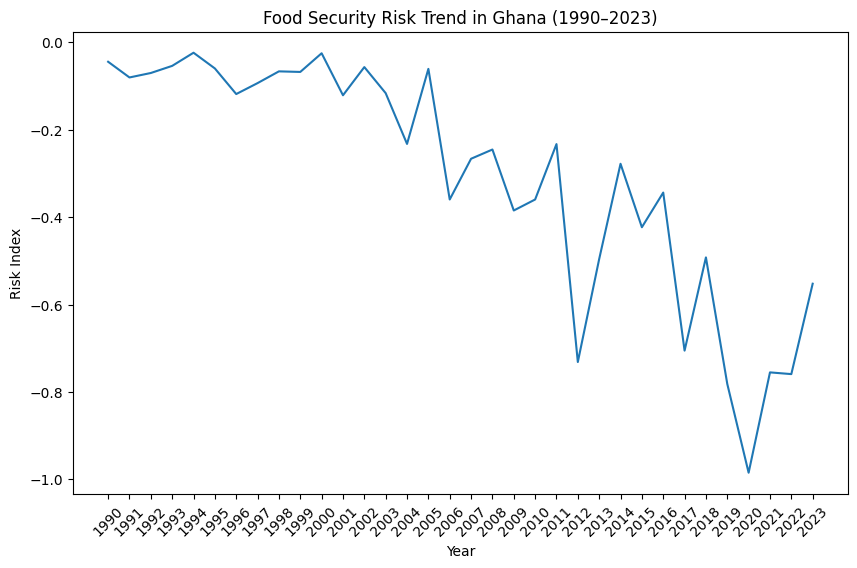

In [14]:
#A Food Security Risk Indicator
#We combine key variables into one index that shows risk over time.
# Normalize variables

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df.copy()

df_scaled[["population","food_production_index","fertilizer_consumption"]] = scaler.fit_transform(
    df[["population","food_production_index","fertilizer_consumption"]]
)

# Create Food Security Risk Score
df_scaled["food_security_risk"] = (
    df_scaled["population"]    - df_scaled["food_production_index"]
    - df_scaled["fertilizer_consumption"]
)

# Plot risk trend
plt.figure(figsize=(10,6))

sns.lineplot(data=df_scaled, x="year", y="food_security_risk")

plt.title("Food Security Risk Trend in Ghana (1990–2023)")
plt.xlabel("Year")
plt.ylabel("Risk Index")

plt.xticks(rotation=45)

plt.savefig("food_security_risk_index.png", dpi=300, bbox_inches="tight")

plt.show()